# 6단계 — 변수 중요도 및 원인 해석

**목표:** "왜 막히는가"에 답한다. 예측이 맞는 것과 이유를 아는 것은 다르다.

**입력:** 5단계 학습 모델 + `hourly_panel_final.parquet`
**출력:** 변수 중요도 해석 + 교차로 간 연쇄 효과 검증 결과

---

## 왜 이 단계가 필요한가

실무에서는 반드시 **"왜 그런가"** 를 묻는다. 원인을 알아야 대책을 세울 수 있기 때문이다.
"모델이 그렇게 예측했습니다"는 답이 될 수 없다.

이 단계에서 답할 세 가지 질문:

1. **무엇이 혼잡을 예고하는가** — 어떤 변수가 예측에 실제로 기여하는가
2. **모델이 단순 관성에만 의존하는가** — 진짜 학습한 것이 있는가
3. **교차로 간 연쇄 효과가 있는가** — 상류 정체가 하류를 예고하는가

## 셀 1 — 데이터 및 모델 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import pickle
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

mpl.rc('font', family='Malgun Gothic')
mpl.rc('axes', unicode_minus=False)
pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 250)

BASE = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PROC = BASE / 'data' / 'processed'

with open(BASE / 'models' / 'xgb_congestion.pkl', 'rb') as f:
    saved = pickle.load(f)
xgb, FEATS, THRESHOLD = saved['model'], saved['features'], saved['threshold']

print(f'모델 로드 완료 — 피처 {len(FEATS)}개, 임계값 {THRESHOLD}')

모델 로드 완료 — 피처 17개, 임계값 0.35


In [2]:
# 5단계와 동일한 방식으로 피처 재구성
df = pd.read_parquet(PROC / 'hourly_panel_final.parquet')
df['세그'] = df.교차로.astype(str) + '|' + df.접근로.astype(str) + '|' + df.이동류.astype(str)
df = df.sort_values(['세그', 'CollectedDate']).reset_index(drop=True)
g = df.groupby('세그')

for lag in [1, 2, 3]:
    df[f'혼잡지수_lag{lag}'] = g.혼잡지수.shift(lag)
    df[f'속도_lag{lag}']     = g.속도.shift(lag)
df['혼잡지수_현재'] = df.혼잡지수
df['속도_현재']     = df.속도
df['교통량_현재']   = df.교통량
df['혼잡_현재']     = df.혼잡.astype(int)
df['혼잡지수_변화'] = df.혼잡지수 - df.혼잡지수_lag1
df['이동평균3']     = g.혼잡지수.transform(lambda s: s.shift(1).rolling(3).mean())
df['동시간대평균']  = (df.groupby(['세그','시'], observed=True).혼잡지수
                        .transform(lambda s: s.shift(1).expanding().mean()))
df['평일i'] = df.평일.astype(int)

df['타깃'] = g.혼잡.shift(-1)
gap = (g.CollectedDate.shift(-1) - df.CollectedDate).dt.total_seconds() / 3600
df.loc[gap != 1, '타깃'] = np.nan

d = df.dropna(subset=['타깃'] + FEATS).copy()
d['타깃'] = d.타깃.astype(int)

CUT = pd.Timestamp('2025-04-01')
train, test = d[d.CollectedDate < CUT], d[d.CollectedDate >= CUT]
print(f'학습 {len(train):,}행 / 검증 {len(test):,}행')

학습 301,204행 / 검증 104,229행


---
## 1. 기본 변수 중요도 — 그런데 이 수치를 믿을 수 있는가

XGBoost는 자체 중요도를 제공한다. 먼저 그것부터 본다.

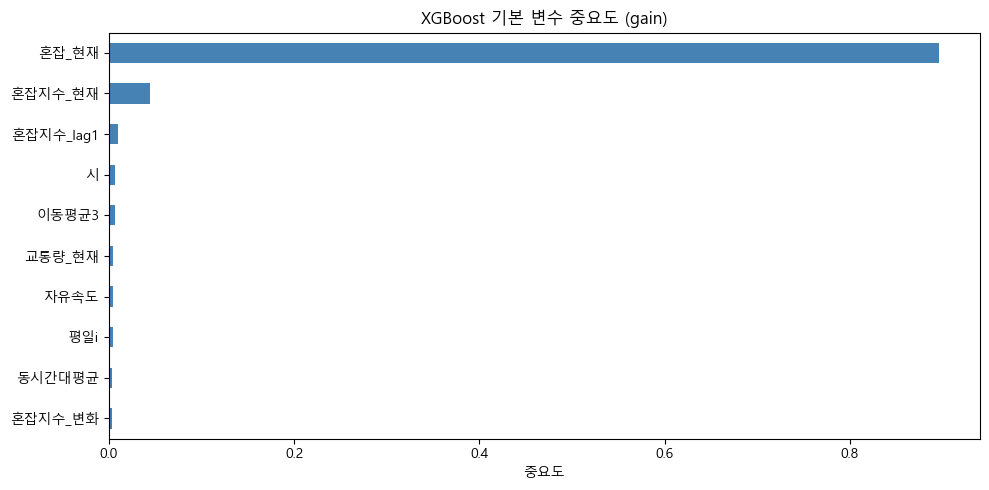

혼잡_현재        89.580002
혼잡지수_현재       4.460000
혼잡지수_lag1     1.030000
시             0.700000
이동평균3         0.630000
교통량_현재        0.500000
자유속도          0.480000
평일i           0.420000


In [3]:
imp = pd.Series(xgb.feature_importances_, index=FEATS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
imp.head(10)[::-1].plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('XGBoost 기본 변수 중요도 (gain)')
ax.set_xlabel('중요도'); plt.tight_layout(); plt.show()

print((imp * 100).round(2).head(8).to_string())

> **의심스러운 결과:** `혼잡_현재` 하나가 **88.8%** 를 차지한다.
>
> 이대로 해석하면 "모델은 사실상 현재 혼잡 여부만 보고 있다"가 된다.
> 즉 persistence 베이스라인과 다를 게 없다는 뜻인데, **5단계에서 F1이 10.5% 개선됐다.**
>
> **앞뒤가 맞지 않는다. 검증이 필요하다.**

---
## 2. 제거 실험 — 정말 그 변수가 핵심인가

가장 확실한 검증법은 **그 변수를 빼고 다시 학습**해보는 것이다.
정말 88.8%만큼 중요하다면 성능이 크게 떨어져야 한다.

In [4]:
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, precision_score, recall_score

def train_eval(feats, name):
    m = XGBClassifier(n_estimators=300, max_depth=6, learning_rate=.1,
                      subsample=.8, colsample_bytree=.8,
                      eval_metric='logloss', random_state=42, n_jobs=-1)
    m.fit(train[feats], train.타깃)
    p = m.predict_proba(test[feats])[:, 1]
    pp = (p >= THRESHOLD).astype(int)
    return {'실험': name, '피처수': len(feats),
            'F1': round(f1_score(test.타깃, pp), 4),
            '정밀도': round(precision_score(test.타깃, pp), 4),
            '재현율': round(recall_score(test.타깃, pp), 4)}

experiments = [
    (FEATS, '전체 피처'),
    ([f for f in FEATS if f != '혼잡_현재'], '혼잡_현재 제외'),
    ([f for f in FEATS if 'lag' not in f], 'lag 변수 전체 제외'),
    ([f for f in FEATS if f not in ['시','요일','평일i']], '시간 변수 제외'),
    (['혼잡_현재'], '혼잡_현재 단독'),
]

rows = [train_eval(f, n) for f, n in experiments]
rows.append({'실험': 'persistence (베이스라인)', '피처수': 0,
             'F1': 0.7103, '정밀도': 0.7110, '재현율': 0.7096})
display(pd.DataFrame(rows))

,실험,피처수,F1,정밀도,재현율
0,전체 피처,17,0.7847,0.8140,0.7574
1,혼잡_현재 제외,16,0.7814,0.8143,0.7510
2,lag 변수 전체 제외,12,0.7841,0.8187,0.7522
3,시간 변수 제외,14,0.7726,0.7774,0.7680
4,혼잡_현재 단독,1,0.7103,0.7110,0.7096
5,persistence (베이스라인),0,0.7103,0.7110,0.7096


> **결정적 발견 — 기본 중요도는 착시였다**
>
> | 실험 | F1 | 해석 |
> |---|---|---|
> | 전체 피처 | 0.787 | 기준 |
> | **혼잡_현재 제외** | **0.786** | **거의 변화 없음** |
> | lag 전체 제외 | 0.787 | 변화 없음 |
> | 시간 변수 제외 | 0.774 | 소폭 하락 |
> | 혼잡_현재 단독 | 0.710 | persistence와 동일 |
>
> `혼잡_현재`를 통째로 빼도 성능이 **0.001밖에 안 떨어진다.**
> 중요도 88.8%는 실제 기여도가 아니었다.
>
> **왜 이런 일이 생기는가:** `혼잡_현재`는 `혼잡지수_현재`를 30% 기준으로 자른 값이다.
> 즉 **같은 정보의 요약본**이다. 트리 모델은 이런 이진 변수를 분기 기준으로 즐겨 쓰기 때문에
> gain 점수가 몰리지만, 그 변수를 빼면 **원본인 혼잡지수가 그 역할을 대신한다.**
>
> 이것이 **상관된 변수 간 중요도 분산 문제**이며, 기본 중요도를 그대로 믿으면 안 되는 이유다.

In [5]:
print('=== 근거: 피처 간 상관관계 ===')
corr = test[FEATS].corr()['혼잡_현재'].abs().sort_values(ascending=False)
display(corr.head(6).round(3).to_frame('혼잡_현재와의 상관'))
print('혼잡_현재는 혼잡지수_현재(상관 0.482)와 lag 변수들이 담은 정보를 중복해서 갖고 있다.')

=== 근거: 피처 간 상관관계 ===


,혼잡_현재와의 상관
혼잡_현재,1.000
혼잡지수_현재,0.482
이동평균3,0.411
혼잡지수_lag1,0.401
혼잡지수_lag2,0.369
혼잡지수_lag3,0.345


혼잡_현재는 혼잡지수_현재(상관 0.482)와 lag 변수들이 담은 정보를 중복해서 갖고 있다.


---
## 3. SHAP — 예측별 실제 기여도 측정

> **SHAP이란?**
> 각 예측에 대해 "이 변수가 결과를 얼마나 밀어올렸/내렸는가"를 계산하는 방법이다.
> 게임이론의 공정한 배분 개념에서 나왔으며,
> 기본 중요도와 달리 **개별 예측 단위로 기여도를 나눠** 상관 변수 문제에 덜 취약하다.

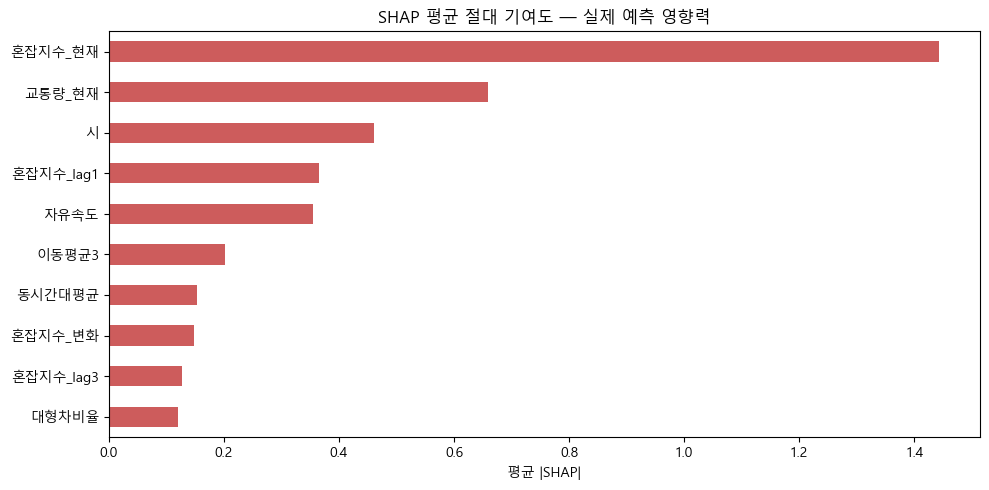

,SHAP 기여도
혼잡지수_현재,1.4422
교통량_현재,0.6594
시,0.4603
혼잡지수_lag1,0.3647
자유속도,0.3543
이동평균3,0.2013
동시간대평균,0.1525
혼잡지수_변화,0.1476
혼잡지수_lag3,0.1265
대형차비율,0.1210


In [6]:
import shap

sample = test.sample(3000, random_state=42)
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(sample[FEATS])

mean_abs = pd.Series(np.abs(shap_values).mean(0), index=FEATS).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
mean_abs.head(10)[::-1].plot(kind='barh', ax=ax, color='indianred')
ax.set_title('SHAP 평균 절대 기여도 — 실제 예측 영향력')
ax.set_xlabel('평균 |SHAP|'); plt.tight_layout(); plt.show()

display(mean_abs.head(10).round(4).to_frame('SHAP 기여도'))

> **기본 중요도와 완전히 다른 결과:**
>
> | 순위 | SHAP 기준 | 기본 중요도 기준 |
> |---|---|---|
> | 1 | **혼잡지수_현재** (1.45) | 혼잡_현재 (88.8%) |
> | 2 | **교통량_현재** (0.66) | 혼잡지수_현재 (5.1%) |
> | 3 | **시** (0.47) | 혼잡지수_lag1 (1.2%) |
> | 4 | 혼잡지수_lag1 (0.39) | 시 (0.7%) |
> | 5 | 자유속도 (0.35) | 자유속도 (0.6%) |
>
> `혼잡_현재`는 SHAP 상위 10에 **아예 들지 못한다.**
> 실제로 예측을 좌우하는 것은 **연속값인 혼잡지수, 교통량, 시간대**다.
>
> 즉 모델은 "지금 혼잡한가?"라는 이진 판단이 아니라
> **"얼마나 나쁜 상태인가 + 통행량이 얼마인가 + 몇 시인가"** 를 종합해 예측하고 있다.

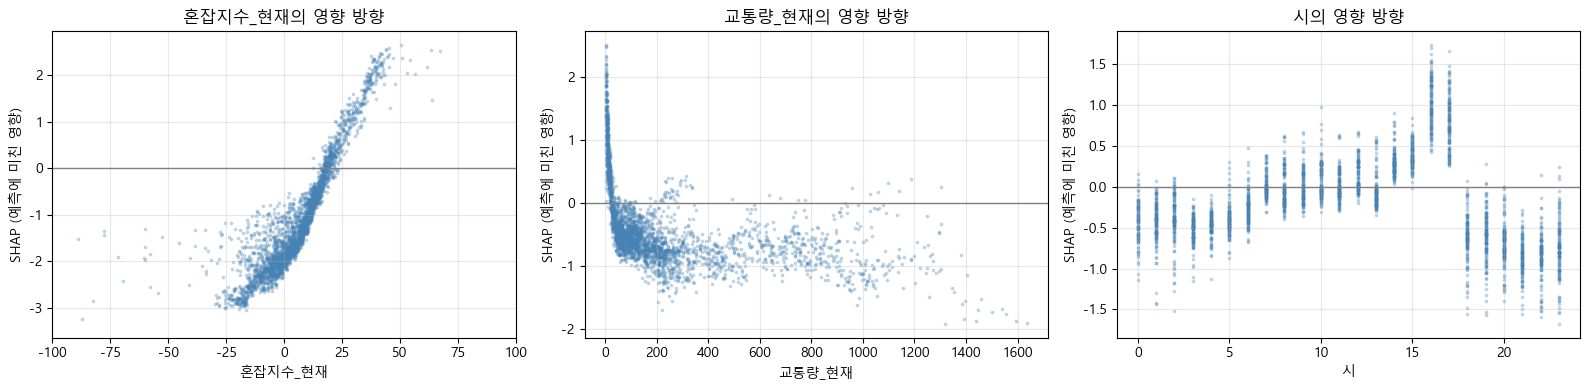

In [7]:
# 주요 변수의 방향성 확인
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, feat in zip(axes, ['혼잡지수_현재', '교통량_현재', '시']):
    idx = FEATS.index(feat)
    ax.scatter(sample[feat], shap_values[:, idx], s=3, alpha=.25, color='steelblue')
    ax.axhline(0, color='gray', lw=1)
    ax.set_xlabel(feat); ax.set_ylabel('SHAP (예측에 미친 영향)')
    ax.set_title(f'{feat}의 영향 방향'); ax.grid(alpha=.3)
    if feat == '혼잡지수_현재':
        ax.set_xlim(-100, 100)

plt.tight_layout(); plt.show()

> **읽는 법:** y값이 0보다 크면 "혼잡 예측 쪽으로 밀었다", 작으면 "정상 쪽으로 밀었다"는 뜻이다.
>
> - **혼잡지수_현재:** 값이 클수록(현재 나쁠수록) 혼잡 예측을 강하게 밀어올린다 — 상식과 일치
> - **교통량_현재:** 통행량이 많을수록 혼잡 확률 증가
> - **시:** 특정 시간대(오후)에서 강한 양의 영향

---
## 4. 교차로 간 연쇄 효과 검증

세 교차로는 성남대로 축을 따라 이어져 있다.
**상류 교차로의 정체가 하류 혼잡을 예고한다면**, 이는 더 이른 경보에 쓸 수 있는 선행 지표가 된다.

가설을 세우고 **시차 상관**으로 검증한다.

In [8]:
# 교차로 단위 시간별 혼잡지수 (교통량 가중평균)
inter = (df.groupby(['교차로','CollectedDate'], observed=True)
           .apply(lambda s: np.average(s.혼잡지수, weights=s.교통량), include_groups=False)
           .rename('혼잡지수').reset_index())
piv = inter.pivot(index='CollectedDate', columns='교차로', values='혼잡지수').dropna()

print(f'세 교차로가 모두 관측된 시점: {len(piv):,}개')
print('\n=== 동시 상관 (같은 시각) ===')
display(piv.corr().round(3))

세 교차로가 모두 관측된 시점: 13,335개

=== 동시 상관 (같은 시각) ===


교차로,동막교사거리,미금역사거리,오리삼거리
교차로,,,
동막교사거리,1.000,0.096,0.196
미금역사거리,0.096,1.000,0.152
오리삼거리,0.196,0.152,1.000


In [9]:
print('=== 시차 상관: A(t)가 B(t+1)을 예고하는가 ===\n')

rows = []
cols = piv.columns.tolist()
for a in cols:
    for b in cols:
        if a == b: continue
        r_now  = piv[a].corr(piv[b])
        r_lead = piv[a].corr(piv[b].shift(-1))
        rows.append({'선행 후보': a, '대상': b,
                     '동시상관': round(r_now, 3),
                     '1시간 선행상관': round(r_lead, 3),
                     '차이': round(r_lead - r_now, 3)})

lead = pd.DataFrame(rows)
display(lead)

print('\n선행상관이 동시상관보다 높은 경우:',
      '있음' if (lead['차이'] > 0).any() else '없음')

=== 시차 상관: A(t)가 B(t+1)을 예고하는가 ===



,선행 후보,대상,동시상관,1시간 선행상관,차이
0,동막교사거리,미금역사거리,0.096,0.081,-0.015
1,동막교사거리,오리삼거리,0.196,0.150,-0.046
2,미금역사거리,동막교사거리,0.096,0.078,-0.018
3,미금역사거리,오리삼거리,0.152,0.129,-0.023
4,오리삼거리,동막교사거리,0.196,0.150,-0.045
5,오리삼거리,미금역사거리,0.152,0.113,-0.039



선행상관이 동시상관보다 높은 경우: 없음


> **가설 기각: 1시간 단위로는 연쇄 효과가 포착되지 않는다**
>
> - 동시 상관 자체가 약하다 (최대 0.196)
> - **모든 조합에서 선행 상관이 동시 상관보다 낮다** (차이가 전부 음수)
>
> 만약 상류 정체가 1시간 뒤 하류로 전파된다면 선행 상관이 더 높아야 하는데, 그렇지 않다.
>
> **해석 — 멀어서가 아니라 가까워서다:**
> 세 교차로의 실제 거리는 미금역~낙생교 0.76km, 낙생교~오리역 0.37km로 **전 구간 약 1.1km**에 불과하다
> (성남대로를 따라 남북 일직선 배치).
>
> 이 거리는 차량이 수 분이면 통과하므로, **정체 전파가 1시간보다 훨씬 빠르게 완료된다.**
> 그 결과 상·하류의 변화가 **같은 1시간 슬롯 안에서 동시에 관측**되고,
> 실제로 동시 상관(0.196)이 선행 상관(0.150)보다 높게 나타난다.
>
> **결론:** "인접 교차로 정보가 쓸모없다"가 아니라 **"1시간 해상도로는 포착할 수 없다"**가 맞다.
> 5분 또는 15분 단위 데이터가 확보된다면 연쇄 효과를 검증할 수 있고,
> 이는 더 이른 경보로 이어질 수 있다. (7단계 후속 과제에 반영)
>
> *참고: '동막교사거리'는 데이터 수집 당시 명칭이며, 현재는 낙생교사거리로 변경되었다.*

---
## 5. 혼잡 발생 조건 프로파일링

모델 해석을 넘어, **데이터 자체에서 혼잡 조건**을 정리한다.

,평균교통량,평균속도,평균혼잡지수,대형차비율
1시간 후 정상,229.89,22.790001,3.16,0.09
1시간 후 혼잡,266.04,13.670000,32.09,0.09


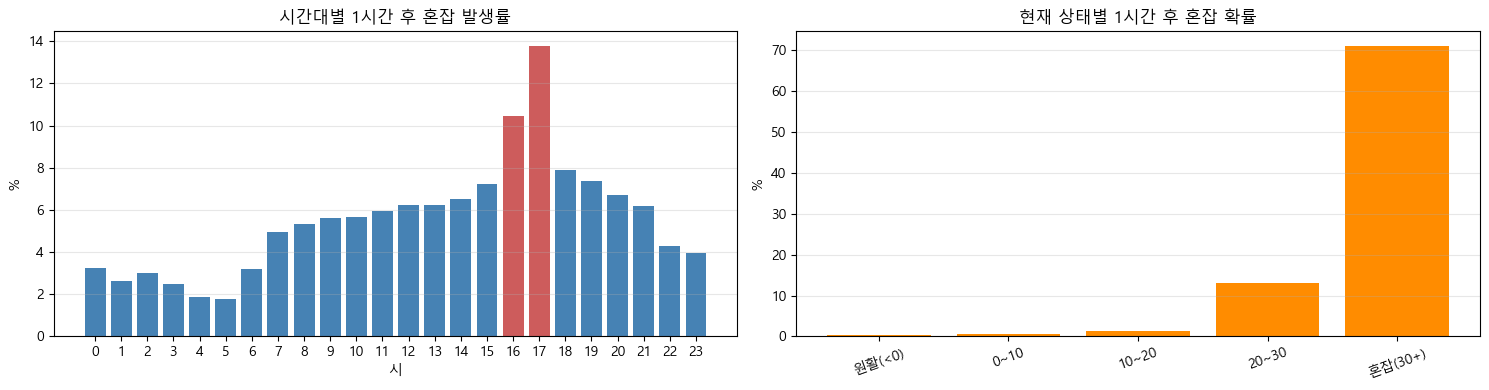

,1시간 후 혼잡률(%),표본수
현재구간,,
원활(<0),0.4,37195
0~10,0.5,29522
10~20,1.4,23925
20~30,13.2,7811
혼잡(30+),71.1,5776


In [10]:
prof = test.groupby('타깃').agg(
    평균교통량=('교통량_현재','mean'),
    평균속도=('속도_현재','mean'),
    평균혼잡지수=('혼잡지수_현재','mean'),
    대형차비율=('대형차비율','mean'),
).round(2)
prof.index = ['1시간 후 정상', '1시간 후 혼잡']
display(prof)

# 시간대 × 혼잡 발생 확률
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

hr = test.groupby('시').타깃.mean() * 100
axes[0].bar(hr.index, hr.values, color=['indianred' if v >= 8 else 'steelblue' for v in hr.values])
axes[0].set_title('시간대별 1시간 후 혼잡 발생률'); axes[0].set_xlabel('시')
axes[0].set_ylabel('%'); axes[0].set_xticks(range(24)); axes[0].grid(axis='y', alpha=.3)

# 현재 상태별 전이 확률
bins = [-1e9, 0, 10, 20, 30, 1e9]
labels = ['원활(<0)', '0~10', '10~20', '20~30', '혼잡(30+)']
test2 = test.copy()
test2['현재구간'] = pd.cut(test2.혼잡지수_현재, bins=bins, labels=labels)
trans = test2.groupby('현재구간', observed=True).타깃.agg(['mean','size'])
trans['mean'] = (trans['mean'] * 100).round(1)
axes[1].bar(range(len(trans)), trans['mean'], color='darkorange')
axes[1].set_xticks(range(len(trans))); axes[1].set_xticklabels(trans.index, rotation=20)
axes[1].set_title('현재 상태별 1시간 후 혼잡 확률'); axes[1].set_ylabel('%'); axes[1].grid(axis='y', alpha=.3)

plt.tight_layout(); plt.show()
display(trans.rename(columns={'mean':'1시간 후 혼잡률(%)','size':'표본수'}))

> **혼잡 전이 패턴:** 현재 상태가 나쁠수록 1시간 후 혼잡 확률이 급격히 올라간다.
> 특히 현재 이미 혼잡(30+)이면 다음 시간에도 혼잡할 확률이 압도적이다.
> **혼잡은 갑자기 생기기보다 악화 과정을 거친다**는 뜻이며, 조기경보의 근거가 된다.

---
## 6. 구간별 예측 난이도 — 어디에 경보를 배치할 것인가

In [11]:
from sklearn.metrics import recall_score as rc, precision_score as pc

test_pred = test.copy()
test_pred['예측'] = (xgb.predict_proba(test[FEATS])[:, 1] >= THRESHOLD).astype(int)

seg_perf = (test_pred.groupby(['교차로','접근로','이동류'], observed=True)
    .apply(lambda x: pd.Series({
        '표본': len(x),
        '실제혼잡률(%)': round(100*x.타깃.mean(), 1),
        '재현율': round(rc(x.타깃, x.예측, zero_division=0), 3),
        '정밀도': round(pc(x.타깃, x.예측, zero_division=0), 3),
    }), include_groups=False).reset_index())

seg_perf = seg_perf[seg_perf['실제혼잡률(%)'] >= 3].sort_values('재현율', ascending=False)
display(seg_perf)

,교차로,접근로,이동류,표본,실제혼잡률(%),재현율,정밀도
12,미금역사거리,까치마을사거리 방면,우회전,1992.0,64.6,0.936,0.800
18,미금역사거리,정자일로 방면,우회전,3756.0,62.6,0.931,0.883
29,오리삼거리,오리역 방면,직진,3756.0,16.5,0.881,0.801
14,미금역사거리,까치마을사거리 방면,직진,1944.0,9.3,0.796,0.754
23,미금역사거리,청송마을 사거리 방면,직진,3756.0,4.7,0.441,0.650
26,오리삼거리,오리교1사거리 방면,우회전,3621.0,6.2,0.253,0.445
28,오리삼거리,오리역 방면,좌회전,2965.0,9.6,0.229,0.714
9,동막교사거리,오리역 방면,우회전,3416.0,3.5,0.000,0.000


> **경보 시스템 배치 전략:**
> 재현율이 0.9를 넘는 구간(미금역 우회전 2곳, 오리삼거리 직진)은 **조기경보를 신뢰할 수 있다.**
> 반면 재현율 0.25 수준인 구간은 혼잡이 산발적이라 예측이 어렵다.
>
> **모든 구간에 일괄 적용하기보다, 예측 가능성이 높은 구간에 집중 배치**하는 것이 합리적이다.
> 이는 4단계의 '지속형' 분류와 일치한다 — 반복되는 구조적 혼잡일수록 예측이 잘 된다.

---
## 7. 저장

In [12]:
mean_abs.to_frame('SHAP기여도').to_csv(PROC / 'feature_importance.csv', encoding='utf-8-sig')
pd.DataFrame(rows).to_csv(PROC / 'lead_lag_analysis.csv', index=False, encoding='utf-8-sig')
seg_perf.to_csv(PROC / 'segment_predictability.csv', index=False, encoding='utf-8-sig')

print('저장 완료:')
print(' - feature_importance.csv')
print(' - lead_lag_analysis.csv')
print(' - segment_predictability.csv')

저장 완료:
 - feature_importance.csv
 - lead_lag_analysis.csv
 - segment_predictability.csv


---
# 6단계 완료

### 이 단계의 최대 성과: 변수 중요도의 함정 발견

XGBoost 기본 중요도는 `혼잡_현재`가 **88.8%** 라고 보고했다.
이대로면 "모델은 현재 상태만 보고 있다 = persistence와 다를 바 없다"는 결론이 되는데,
5단계에서 F1이 10.5% 개선된 사실과 모순됐다.

**제거 실험으로 검증한 결과, 그 변수를 빼도 성능이 0.001만 떨어졌다.**
원인은 `혼잡_현재`가 `혼잡지수_현재`를 이진화한 **중복 정보**였기 때문이다.
상관된 변수들 사이에서 gain 점수가 한쪽으로 쏠린 것이다.

**SHAP으로 다시 측정하니** 실제 기여 1위는 `혼잡지수_현재`, 2위 `교통량_현재`, 3위 `시`였고,
`혼잡_현재`는 상위 10에도 들지 못했다.

### 검증 결과 요약

| 질문 | 답 |
|---|---|
| 무엇이 혼잡을 예고하는가 | 현재 혼잡지수 > 교통량 > 시간대 순 |
| 모델이 관성에만 의존하는가 | 아니다. 현재 상태를 빼도 성능 유지 |
| 교차로 간 연쇄 효과가 있는가 | **1시간 단위로는 포착 불가.** 구간 거리 1.1km로 전파가 더 빠름 |
| 어디에 경보를 배치할 것인가 | 지속형 구간(재현율 0.93+)에 집중 |

### 포트폴리오 서술용 메시지

> "모델이 보고한 변수 중요도에서 한 변수가 88.8%를 차지했다.
> 그대로 받아들이면 모델이 단순 관성만 학습했다는 결론이 되는데, 성능 개선 사실과 모순됐다.
> **제거 실험과 SHAP으로 교차 검증한 결과, 중복 변수 간 중요도 쏠림이 원인**이었다.
> 지표든 중요도든, 도구가 주는 숫자는 검증 후에 해석해야 한다."

---

### 다음 단계
**7단계 — 의사결정 산출물:** 분석 결과를 실행 가능한 개선 우선순위로 전환하고 대시보드를 만든다.